# Market Technical Indicators

## Process the Data

- **Purpose:** Calculate the established technical-indicator feature set from fixed-universe dollar bars.
- **Settings:** `window=14` bars where applicable; other indicator parameters use FinanceToolkit defaults; `Adj Close=Close`; `rounding=4`; exclude four breadth indicators.
- **Data:** Fixed-universe dollar bars produce the persisted 48-indicator FinanceToolkit feature artifact.
- **Findings:**
- **Decision:** Reuse the artifact when its source identity matches.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.preprocessing.market_data import ResearchPaths

PROJECT_ROOT = Path.cwd().resolve().parents[1]
PERIOD = "2025-02-01_2025-12-31"
MANIFEST_PATH = PROJECT_ROOT / "data/preprocessing/universe/sp500_2025.csv"
EXPECTED_SECURITIES = 503
WINDOW = 14
paths = ResearchPaths(PROJECT_ROOT, period=PERIOD)
DISPLAY_SYMBOL = "AAPL"  # Inspection only; every manifest symbol is processed.

from src.preprocessing.market_technical_indicators import build_technical_features
from src.preprocessing.market_technical_indicators import TECHNICAL_FEATURES
started = perf_counter()
technical_report = build_technical_features(
    paths,
    manifest_path=MANIFEST_PATH,
    expected_securities=EXPECTED_SECURITIES,
    window=WINDOW,
    show_progress=True,
)
elapsed_seconds = perf_counter() - started
cached = technical_report["status"].eq("cached")
display(pd.Series({
    "completed_symbols": len(technical_report),
    "processed_symbols": (~cached).sum(),
    "cached_symbols": cached.sum(),
    "processed_rows": technical_report.loc[~cached].get("rows", pd.Series(dtype=float)).sum(),
    "elapsed_seconds": elapsed_seconds,
}))
display(technical_report.head(5))
technical_path = paths.feature(DISPLAY_SYMBOL, "technical")
technical_features = pd.read_parquet(technical_path)
feature_columns = list(TECHNICAL_FEATURES)
technical_path

Technical indicators:   0%|          | 0/503 [00:00<?, ?it/s]

completed_symbols    5.030000e+02
processed_symbols    2.510000e+02
cached_symbols       2.520000e+02
processed_rows       2.491614e+07
elapsed_seconds      1.850937e+02
dtype: float64

,symbol,status,rows
0,A,cached,NaN
1,AAPL,cached,NaN
2,ABBV,cached,NaN
3,ABNB,cached,NaN
4,ABT,cached,NaN


PosixPath('/Users/kwonjunhyuk9/Documents/financial-machine-learning/data/preprocessing/market/stock/AAPL/features/technical.parquet')

## Take a Quick Look at the Data Structure

- **Purpose:** Inspect the single-symbol schema and the distributions of 48 numeric indicators.
- **Settings:**
- **Data:** Inspect a temporary frame derived from the persisted indicator table.
- **Findings:**
- **Decision:** Replace infinities only in the temporary frame and leave the persisted table unchanged.

In [2]:
technical_features.head()

,start,end,symbol,On-Balance Volume,Accumulation/Distribution Line,Chaikin Oscillator,Money Flow Index,Williams %R,Aroon Indicator Up,Aroon Indicator Down,...,Bollinger Band Middle,Bollinger Band Lower,True Range,Average True Range,Keltner Channel Upper,Keltner Channel Middle,Keltner Channel Lower,Donchian Channel Upper,Donchian Channel Middle,Donchian Channel Lower
0,2025-01-03 14:30:00.017330+00:00,2025-01-03 14:30:01.443075+00:00,AAPL,NaN,6.000830e+05,0.0000,NaN,NaN,NaN,NaN,...,NaN,NaN,0.3700,0.3700,244.1400,243.4000,242.6600,NaN,NaN,NaN
1,2025-01-03 14:30:01.443270+00:00,2025-01-03 14:30:01.443338+00:00,AAPL,NaN,1.179803e+06,184456.3636,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0200,0.1950,243.7900,243.4000,243.0100,NaN,NaN,NaN
2,2025-01-03 14:30:01.443351+00:00,2025-01-03 14:30:04.102482+00:00,AAPL,NaN,1.304428e+06,282800.4339,NaN,NaN,NaN,NaN,...,NaN,NaN,0.8500,0.4133,244.2267,243.4000,242.5733,NaN,NaN,NaN
3,2025-01-03 14:30:04.102762+00:00,2025-01-03 14:30:12.705020+00:00,AAPL,-124727.0,1.259073e+06,282891.7455,NaN,NaN,NaN,NaN,...,NaN,NaN,1.1000,0.5850,244.4700,243.3000,242.1300,NaN,NaN,NaN
4,2025-01-03 14:30:12.705231+00:00,2025-01-03 14:30:40.521807+00:00,AAPL,-310.0,1.261884e+06,258106.1779,NaN,NaN,NaN,NaN,...,NaN,NaN,0.9515,0.6583,244.5679,243.2513,241.9347,NaN,NaN,NaN


In [3]:
technical_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 100679 entries, 0 to 100678
Data columns (total 51 columns):
 #   Column                                    Non-Null Count   Dtype              
---  ------                                    --------------   -----              
 0   start                                     100679 non-null  datetime64[us, UTC]
 1   end                                       100679 non-null  datetime64[us, UTC]
 2   symbol                                    100679 non-null  str                
 3   On-Balance Volume                         98414 non-null   float64            
 4   Accumulation/Distribution Line            100554 non-null  float64            
 5   Chaikin Oscillator                        100679 non-null  float64            
 6   Money Flow Index                          100666 non-null  float64            
 7   Williams %R                               100666 non-null  float64            
 8   Aroon Indicator Up                        100666 non-nu

In [4]:
technical_features["symbol"].value_counts(dropna=False)

symbol
AAPL    100679
Name: count, dtype: int64

In [5]:
technical_features[feature_columns].describe()

,On-Balance Volume,Accumulation/Distribution Line,Chaikin Oscillator,Money Flow Index,Williams %R,Aroon Indicator Up,Aroon Indicator Down,Commodity Channel Index,Relative Vigor Index,Force Index,...,Bollinger Band Middle,Bollinger Band Lower,True Range,Average True Range,Keltner Channel Upper,Keltner Channel Middle,Keltner Channel Lower,Donchian Channel Upper,Donchian Channel Middle,Donchian Channel Lower
count,9.841400e+04,1.005540e+05,1.006790e+05,100666.000000,100666.000000,100666.000000,100666.000000,100653.000000,1.006660e+05,1.006660e+05,...,100666.000000,100666.000000,100679.000000,100679.000000,100679.00000,100679.000000,100679.000000,100666.000000,100666.000000,100666.000000
mean,2.961664e+07,7.740138e+07,7.123767e+03,50.412621,-48.375201,55.913690,57.226659,0.879705,-inf,1.709891e+03,...,229.672719,229.169463,0.584586,0.584609,230.84368,229.674461,228.505242,230.768930,229.597213,228.425497
std,2.977690e+07,6.594746e+07,1.736201e+05,17.183163,33.543528,35.152065,34.979134,93.699434,NaN,5.676886e+05,...,26.691324,26.742865,1.320451,0.611017,26.52656,26.689011,26.906039,26.499826,26.571134,26.789421
min,-1.396125e+07,-1.036422e+07,-4.428879e+06,0.000000,-100.000000,7.142900,7.142900,-859.649600,-inf,-7.551010e+07,...,169.644300,168.618000,0.000000,0.049600,171.25120,169.667600,162.378500,170.700000,169.955000,169.210100
25%,2.415888e+06,2.347224e+07,-8.624484e+04,35.912525,-80.555600,21.428600,21.428600,-58.440000,6.126000e-01,-1.315465e+05,...,207.767725,207.280050,0.234500,0.286300,209.00185,207.777050,206.456100,209.230000,207.800000,206.050100
50%,2.495396e+07,5.179165e+07,5.147406e+03,50.018600,-47.496150,57.142900,57.142900,2.603900,9.936000e-01,0.000000e+00,...,228.430250,227.978850,0.352400,0.410600,229.41560,228.440100,227.401600,229.490000,228.550000,227.440000
75%,5.290739e+07,1.405862e+08,9.807301e+04,64.240900,-15.873000,92.857100,92.857100,60.233700,1.625875e+00,1.320084e+05,...,248.061925,247.535125,0.549400,0.648000,249.24580,248.049150,247.050250,249.490000,247.835000,247.040000
max,9.561882e+07,2.067182e+08,7.845980e+06,100.000000,-0.000000,100.000000,100.000000,849.177200,1.242200e+04,5.546833e+07,...,287.851100,287.501700,34.323400,14.058800,293.74880,287.913900,286.973900,288.630000,287.795000,287.340000


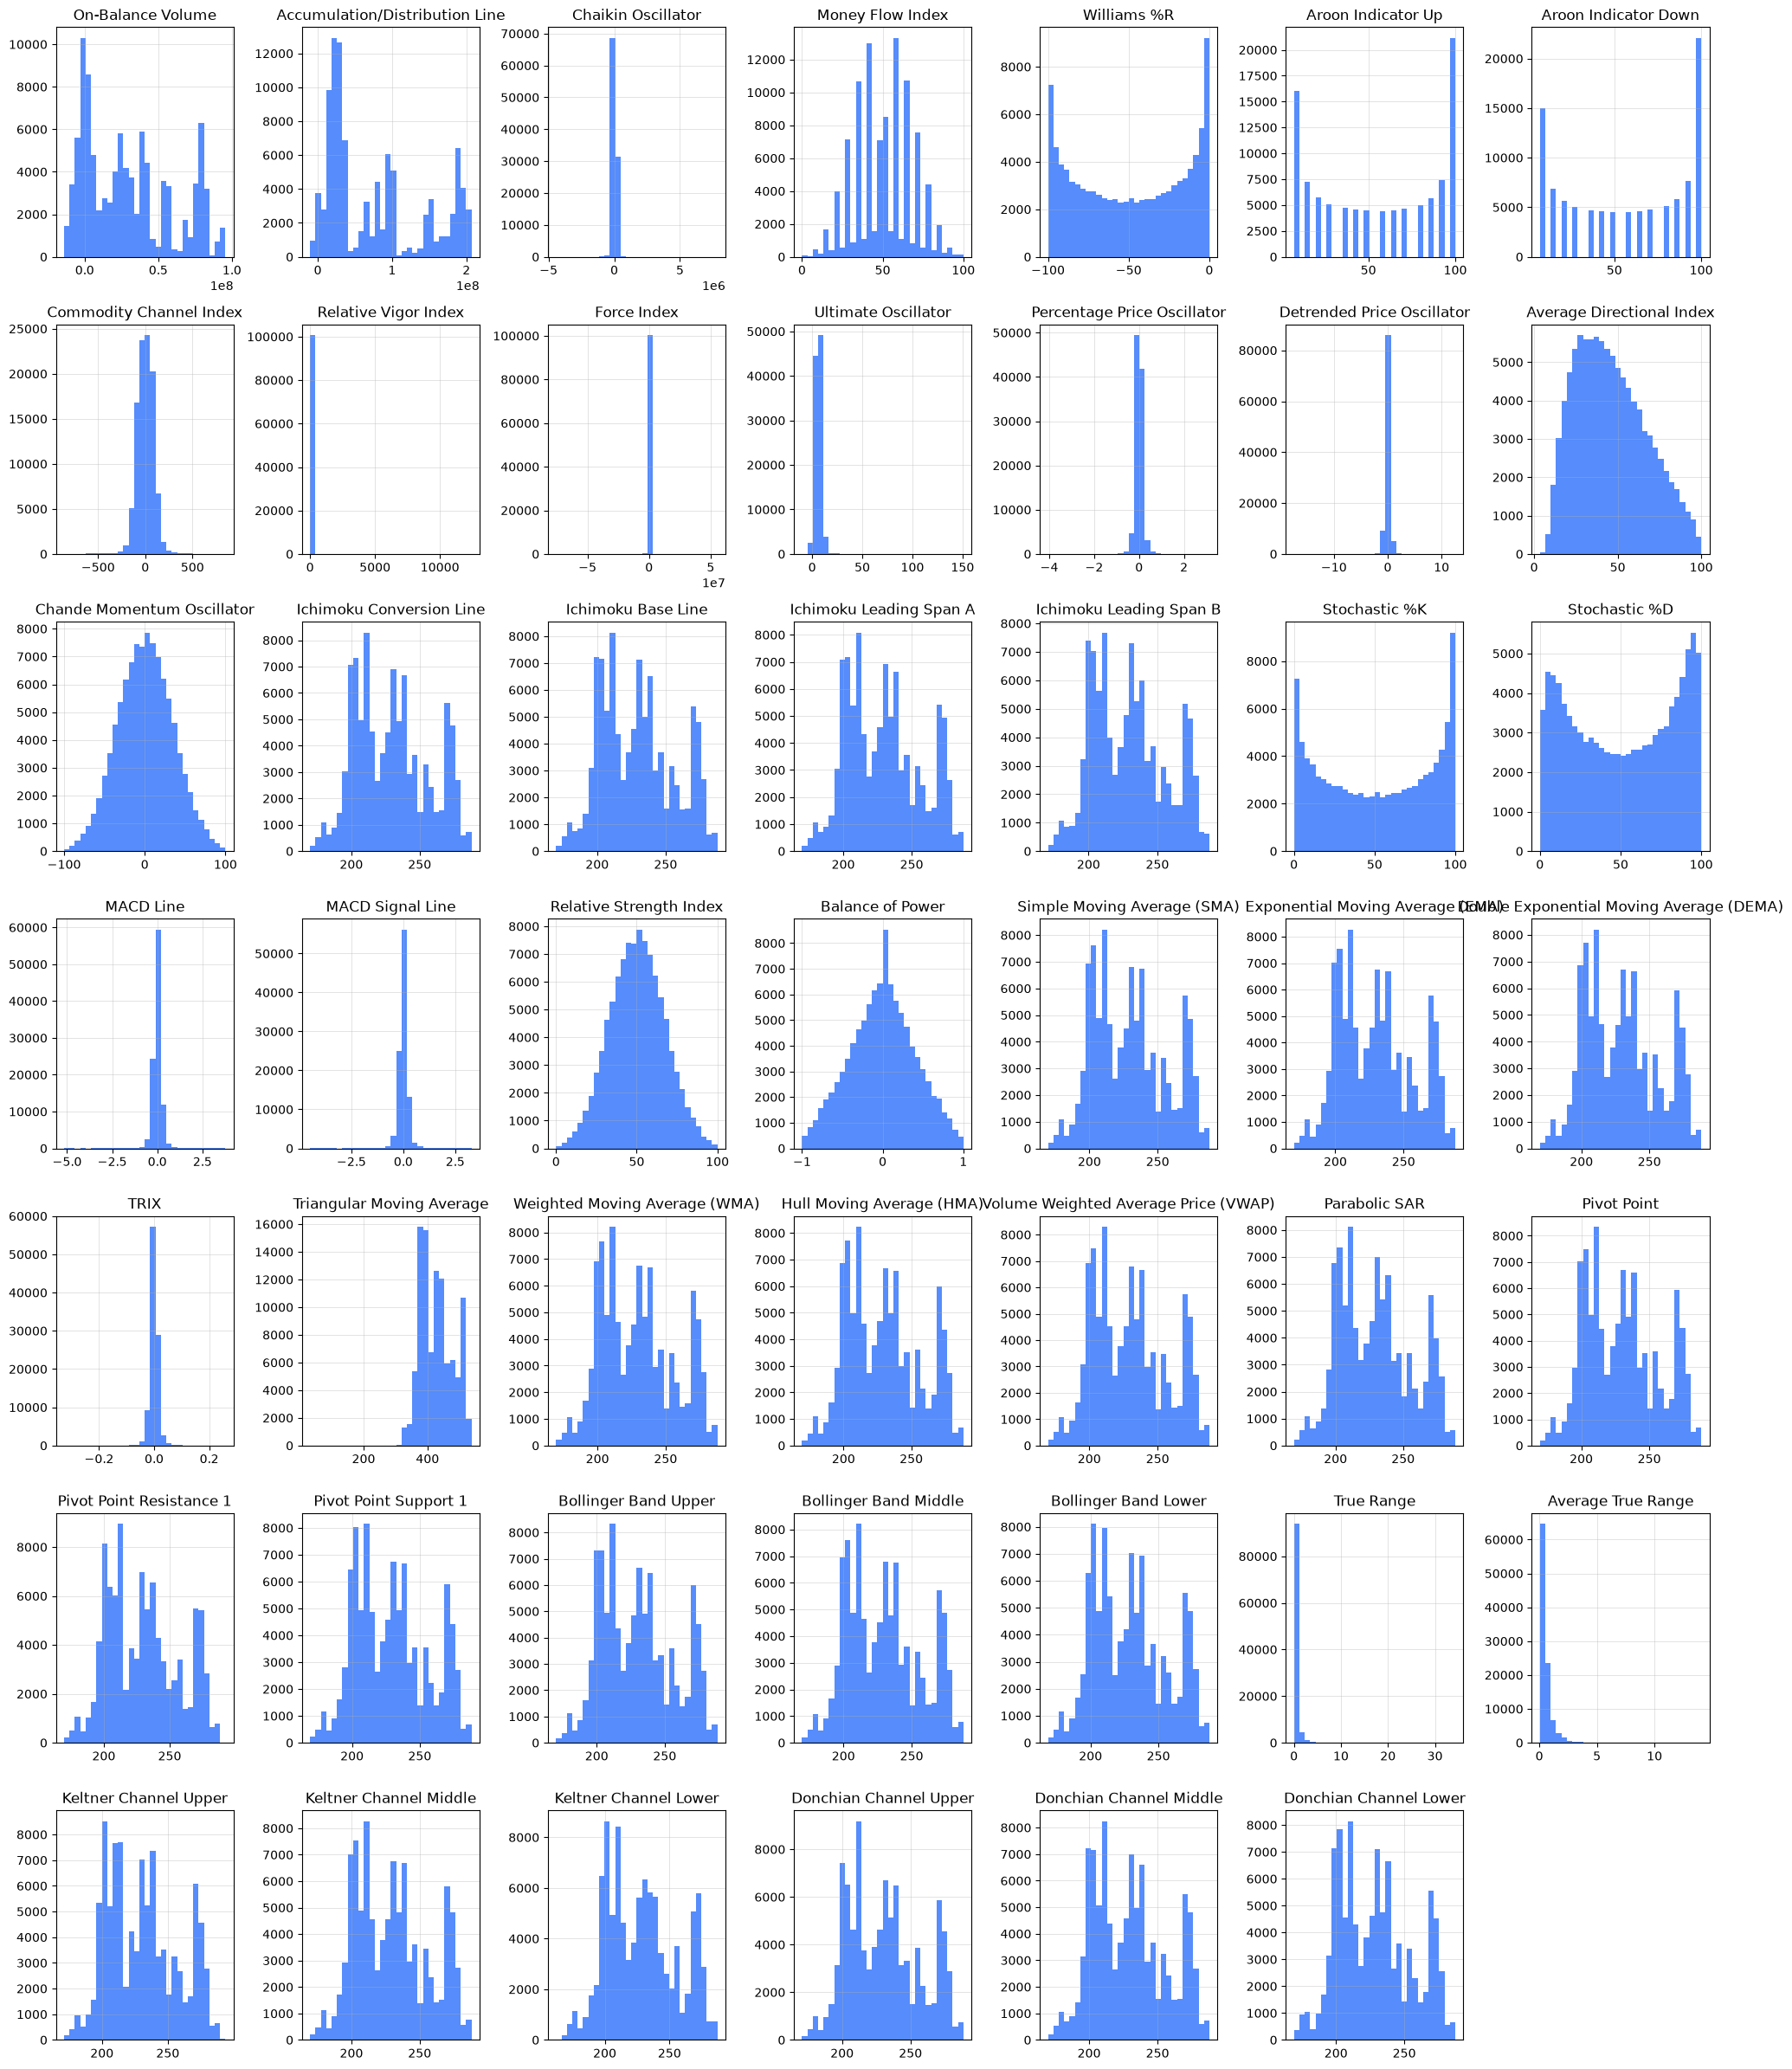

In [6]:
technical_features[feature_columns].replace(
    [np.inf, -np.inf], np.nan
).hist(bins=30, figsize=(20, 24))
plt.tight_layout()
plt.show()